# PriceIt — Airbnb Price Prediction

This notebook builds a machine learning model to predict Airbnb listing prices using structured listing data (bedrooms, bathrooms, amenities, neighborhood, etc.).

**Pipeline overview:**
1. Data loading & cleaning
2. Exploratory data analysis
3. Feature engineering
4. Model training & comparison (Linear Regression, Random Forest, XGBoost)
5. Evaluation & export

## 1. Setup

In [ ]:
import re
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Data Loading & Cleaning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Colab Notebooks/PriceIt/data/listings.csv.gz'

Mounted at /content/drive


In [ ]:
df = pd.read_csv(file_path)
print(f"Loaded {len(df):,} listings with {df.shape[1]} columns")

Loaded 8,660 listings with 79 columns


In [ ]:
# Clean price column — strip $ and commas, cast to float
df["price"] = df["price"].str.replace(r"[\$,]", "", regex=True).astype(float)

# Drop rows with missing price
df = df.dropna(subset="price")

# Remove top 5% outliers
upper_limit = df["price"].quantile(0.95)
df = df[df["price"] <= upper_limit]

# Log-transform prices to reduce skew
df["log_price"] = np.log1p(df["price"])

print(f"After cleaning: {len(df):,} listings")
print(f"Price range: ${df['price'].min():.0f} – ${df['price'].max():.0f}")

After cleaning: 7,433 listings
Price range: $13 – $587


In [ ]:
# Impute missing bathroom values from bathrooms_text
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text_lower = text.lower()
    if "half" in text_lower:
        return 0.5
    match = re.search(r"[\d\.]+", text)
    return float(match.group()) if match else np.nan

df["bathrooms_imputed"] = df["bathrooms"].fillna(df["bathrooms_text"].apply(parse_bathrooms))
df["bathrooms"] = df["bathrooms_imputed"].fillna(df["bathrooms_imputed"].median())
df.drop(columns="bathrooms_imputed", inplace=True)

# Drop the ~6 rows with missing bedrooms
df = df.dropna(subset=["bedrooms"])

print(f"Final dataset: {len(df):,} listings")

Final dataset: 7,427 listings


## 3. Exploratory Data Analysis

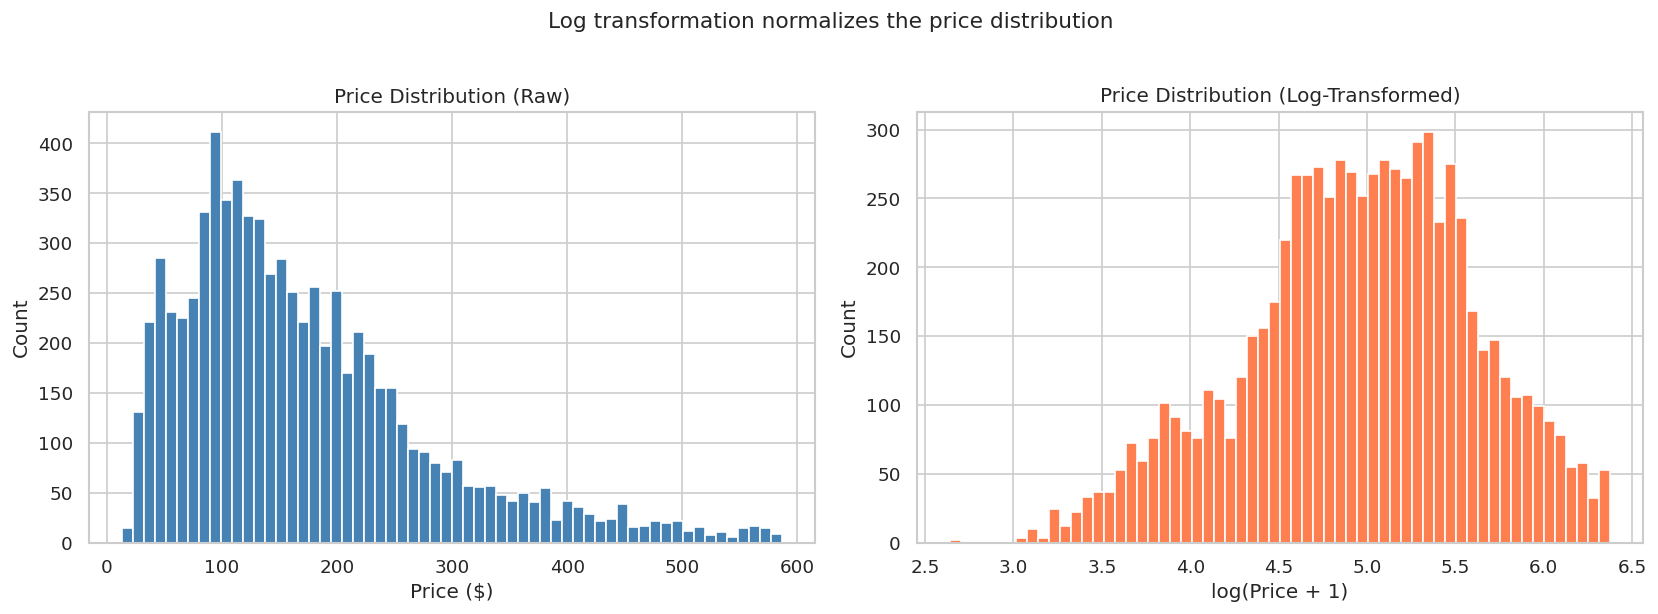

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (raw)
axes[0].hist(df["price"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution (Raw)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

# Price distribution (log-transformed)
axes[1].hist(df["log_price"], bins=60, color="coral", edgecolor="white")
axes[1].set_title("Price Distribution (Log-Transformed)")
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Count")

plt.suptitle("Log transformation normalizes the price distribution", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

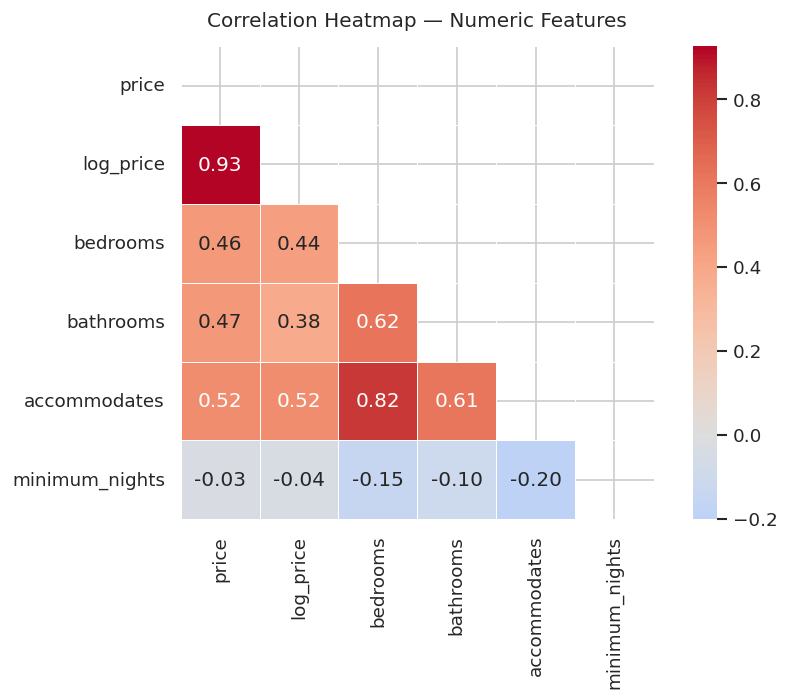

In [ ]:
# Correlation heatmap — numeric features vs log_price
numeric_cols = ["price", "log_price", "bedrooms", "bathrooms", "accommodates", "minimum_nights"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap — Numeric Features", pad=12)
plt.tight_layout()
plt.show()

/tmp/ipython-input-480681779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="price", order=order, palette="Set2")


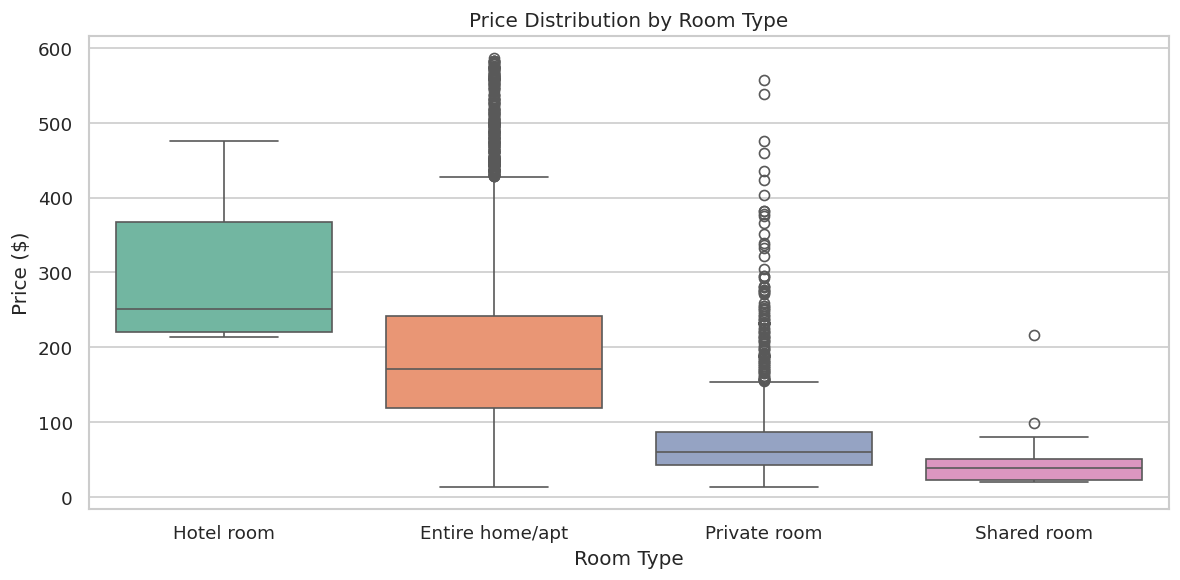

In [ ]:
# Price by room type
plt.figure(figsize=(10, 5))
order = df.groupby("room_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="price", order=order, palette="Set2")
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-476244054.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bed, x="bedrooms", y="price", palette="Blues_d")


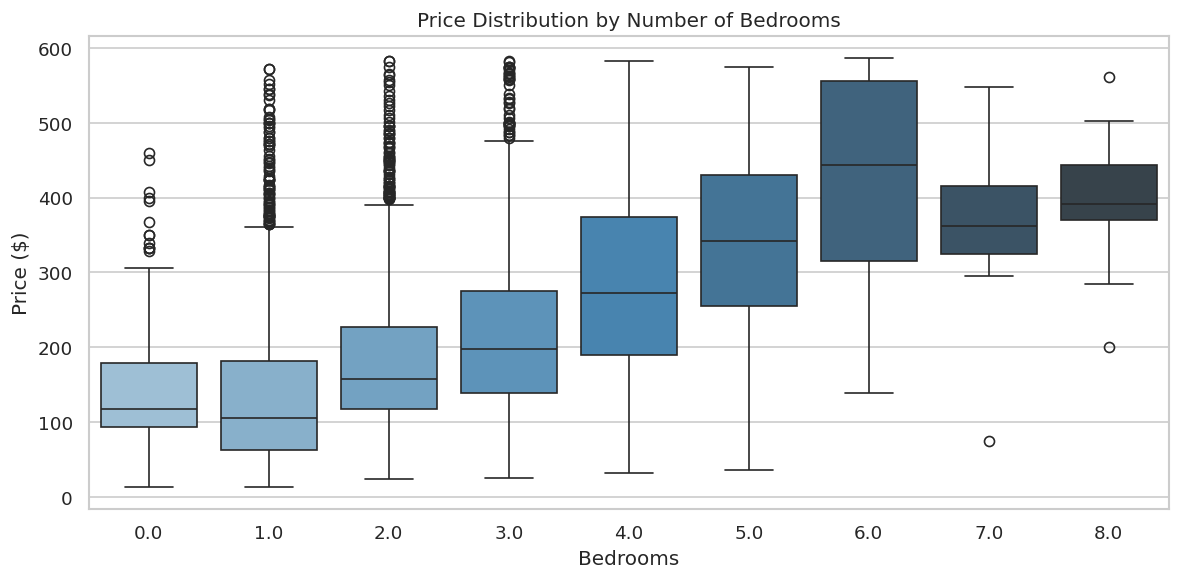

In [ ]:
# Price vs. bedrooms
plt.figure(figsize=(10, 5))
bedroom_counts = df["bedrooms"].value_counts()
valid_bedrooms = bedroom_counts[bedroom_counts >= 10].index
df_bed = df[df["bedrooms"].isin(valid_bedrooms)]

sns.boxplot(data=df_bed, x="bedrooms", y="price", palette="Blues_d")
plt.title("Price Distribution by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

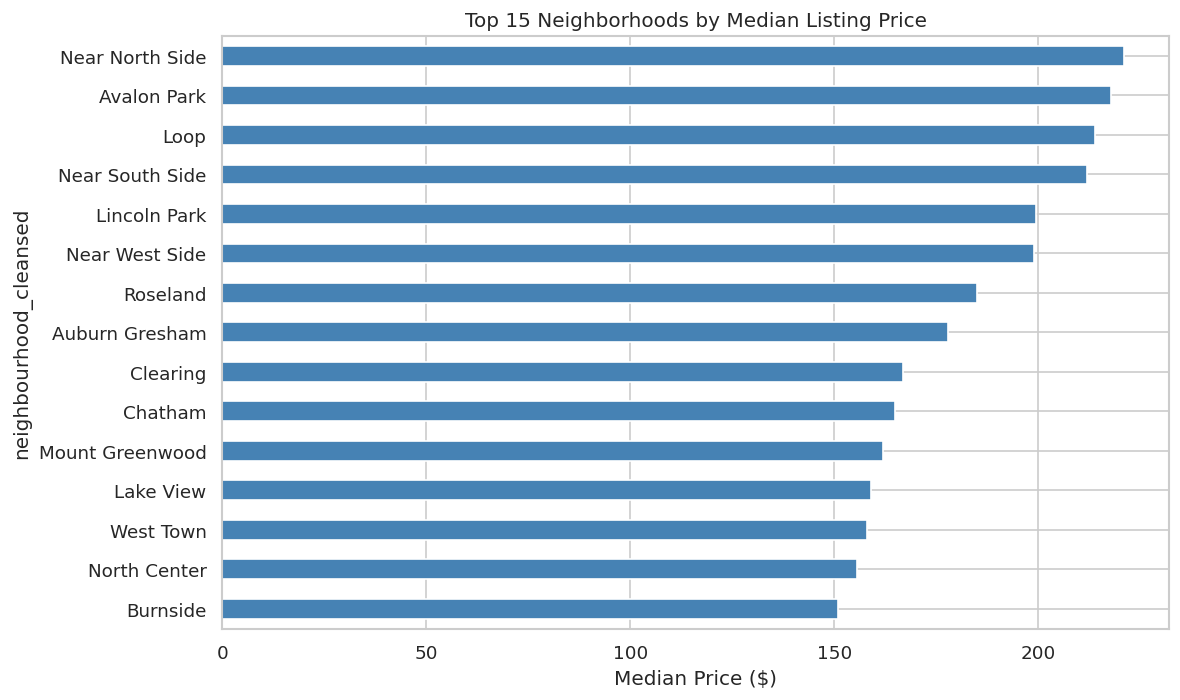

In [ ]:
# Top 15 most expensive neighborhoods by median price
top_neighborhoods = (
    df.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
top_neighborhoods.plot(kind="barh", color="steelblue")
plt.title("Top 15 Neighborhoods by Median Listing Price")
plt.xlabel("Median Price ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [ ]:
# Encode categorical features
df = pd.get_dummies(df, columns=["neighbourhood_cleansed"], drop_first=True)
df = pd.get_dummies(df, columns=["room_type"], drop_first=True)
df["instant_bookable_encoded"] = df["instant_bookable"].map({"t": 1, "f": 0})

# Encode property type — keep top 10, group rest as "Other"
top_types = df["property_type"].value_counts().nlargest(10).index
df["property_type_cleaned"] = df["property_type"].apply(lambda x: x if x in top_types else "Other")
df = pd.get_dummies(df, columns=["property_type_cleaned"], drop_first=True)

In [ ]:
# Derived features
df["amenities_count"] = df["amenities"].apply(lambda x: len(x.split(",")))
df["guests_per_bedroom"] = df["accommodates"] / df["bedrooms"].replace(0, 1)
df["bathrooms_per_guest"] = df["bathrooms"] / df["accommodates"].replace(0, 1)
df["guests_per_night"] = df["accommodates"] / df["minimum_nights"].replace(0, 1)

# Binary amenity flags for high-value amenities
top_amenities = [
    "City skyline view", "Pool", "Hot tub", "Air conditioning",
    "Washer", "Dryer", "Gym", "Balcony", "Kitchen", "Wifi", "Lake access"
]
for amenity in top_amenities:
    col_name = amenity.lower().replace(" ", "_")
    df[col_name] = df["amenities"].str.contains(amenity, case=False, na=False).astype(int)

print("Feature engineering complete")

Feature engineering complete


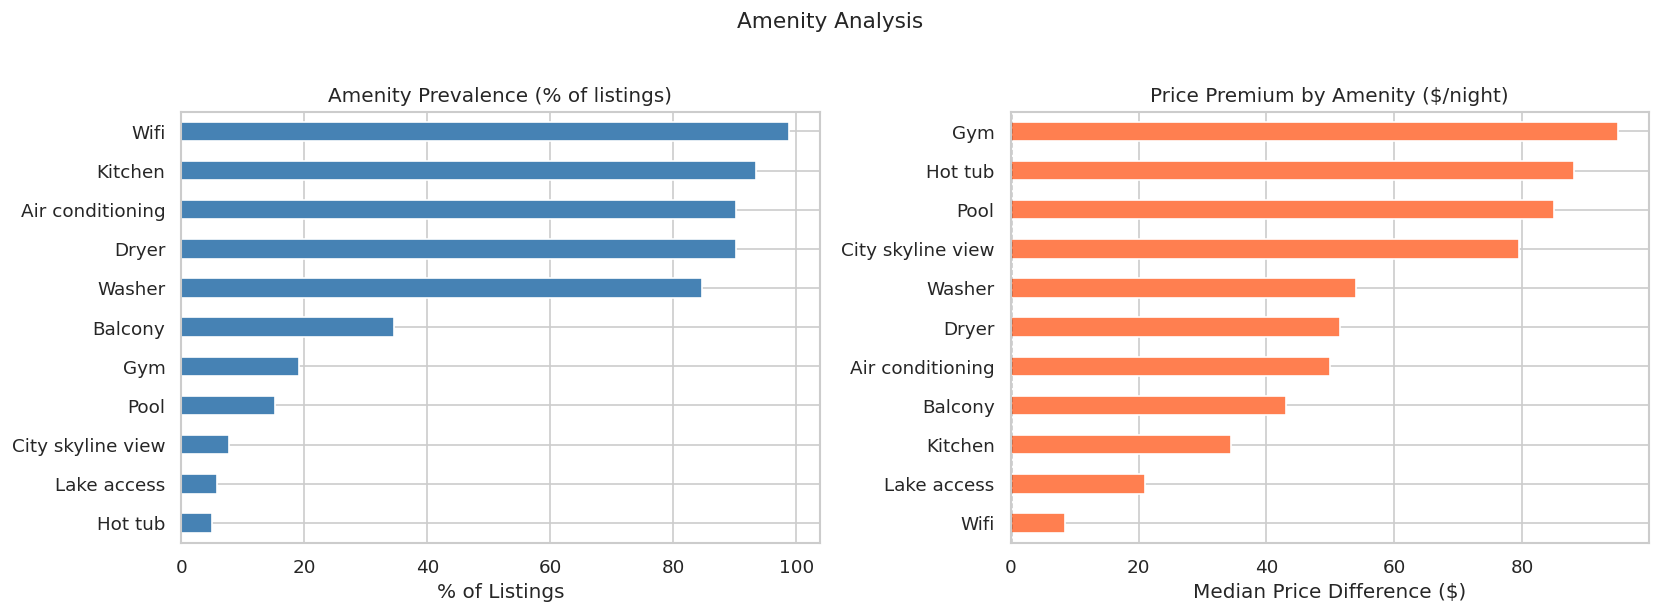

In [ ]:
# Visualize amenity prevalence and average price impact
amenity_cols = [a.lower().replace(" ", "_") for a in top_amenities]
amenity_stats = pd.DataFrame({
    "prevalence": [df[col].mean() * 100 for col in amenity_cols],
    "median_price_with": [df[df[col] == 1]["price"].median() for col in amenity_cols],
    "median_price_without": [df[df[col] == 0]["price"].median() for col in amenity_cols],
}, index=top_amenities)
amenity_stats["price_premium"] = amenity_stats["median_price_with"] - amenity_stats["median_price_without"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amenity_stats["prevalence"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Amenity Prevalence (% of listings)")
axes[0].set_xlabel("% of Listings")

amenity_stats["price_premium"].sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Price Premium by Amenity ($/night)")
axes[1].set_xlabel("Median Price Difference ($)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Amenity Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Define feature sets
numeric_features = [
    "bedrooms", "bathrooms", "accommodates", "amenities_count",
    "guests_per_bedroom", "minimum_nights", "bathrooms_per_guest",
    "guests_per_night"
] + amenity_cols

categorical_features = (
    [col for col in df.columns if "property_type_" in col or "neighbourhood_cleansed_" in col]
    + ["instant_bookable_encoded"]
)

X = df[numeric_features + categorical_features]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} samples | Test: {len(X_test):,} samples")
print(f"Total features: {X.shape[1]}")

Train: 5,941 samples | Test: 1,486 samples
Total features: 105


## 5. Model Training & Evaluation

We compare three models in order of increasing complexity:
1. **Linear Regression** — baseline
2. **Random Forest** — ensemble of decision trees, tuned via grid search
3. **XGBoost** — gradient boosted trees (best performer)

In [ ]:
# --- Linear Regression (Baseline) ---
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_r2 = lr.score(X_train, y_train)
lr_test_r2 = lr.score(X_test, y_test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))

print(f"Linear Regression — Train R²: {lr_train_r2:.3f} | Test R²: {lr_test_r2:.3f} | Test RMSE: {lr_test_rmse:.3f}")

Linear Regression — Train R²: 0.682 | Test R²: 0.654 | Test RMSE: 0.382


In [ ]:
# --- Random Forest with Grid Search ---
param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4, 6, 8],
    "max_depth": [None, 4, 8]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

rf = grid_search.best_estimator_
rf_train_r2 = rf.score(X_train, y_train)
rf_test_r2 = rf.score(X_test, y_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))

print(f"Best RF params: {grid_search.best_params_}")
print(f"Random Forest  — Train R²: {rf_train_r2:.3f} | Test R²: {rf_test_r2:.3f} | Test RMSE: {rf_test_rmse:.3f}")

Best RF params: {'max_depth': None, 'min_samples_split': 6, 'n_estimators': 300}
Random Forest  — Train R²: 0.935 | Test R²: 0.731 | Test RMSE: 0.337


In [ ]:
# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_train_r2 = r2_score(y_train, xgb.predict(X_train))
xgb_test_r2 = r2_score(y_test, xgb.predict(X_test))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb.predict(X_test)))

print(f"XGBoost        — Train R²: {xgb_train_r2:.3f} | Test R²: {xgb_test_r2:.3f} | Test RMSE: {xgb_test_rmse:.3f}")

XGBoost        — Train R²: 0.851 | Test R²: 0.739 | Test RMSE: 0.331


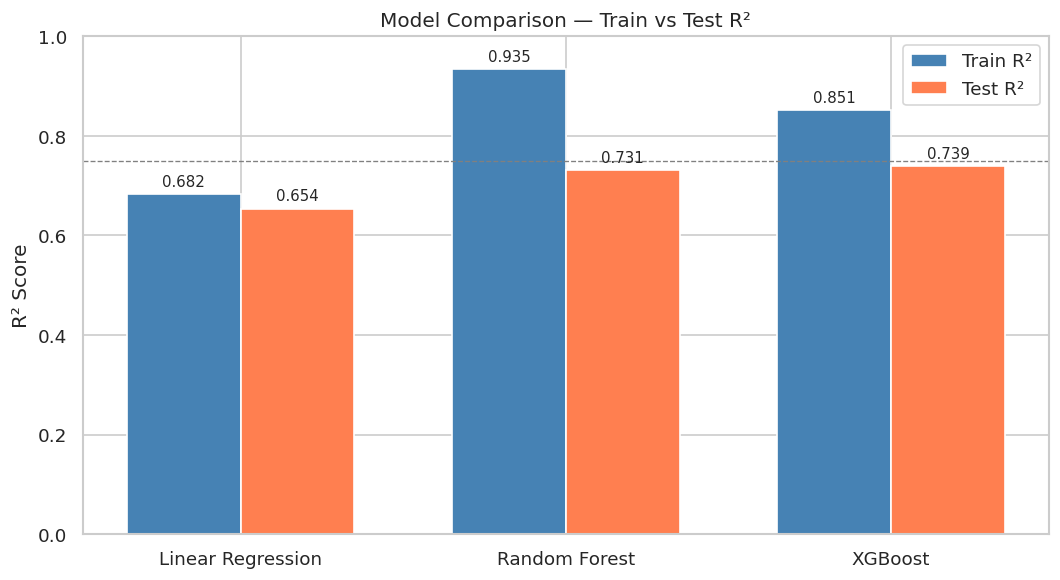

In [ ]:
# Model comparison chart
models = ["Linear Regression", "Random Forest", "XGBoost"]
train_r2 = [lr_train_r2, rf_train_r2, xgb_train_r2]
test_r2  = [lr_test_r2,  rf_test_r2,  xgb_test_r2]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_r2, width, label="Train R²", color="steelblue")
ax.bar(x + width/2, test_r2,  width, label="Test R²",  color="coral")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("R² Score")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Train vs Test R²")
ax.legend()
ax.axhline(0.75, color="gray", linestyle="--", linewidth=0.8, label="0.75 reference")

for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
            f"{rect.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 6. XGBoost Deep Dive

XGBoost is selected as the final model with the best test R² and dollar-level accuracy.

In [ ]:
y_pred_test = xgb.predict(X_test)

# Dollar-scale metrics
actual_dollars = np.expm1(y_test)
pred_dollars = np.expm1(y_pred_test)

rmse_dollars = np.sqrt(mean_squared_error(actual_dollars, pred_dollars))
mae_dollars = np.mean(np.abs(pred_dollars - actual_dollars))
median_ae = np.median(np.abs(pred_dollars - actual_dollars))
mape = np.mean(np.abs(pred_dollars - actual_dollars) / actual_dollars) * 100

print(f"RMSE:                  ${rmse_dollars:.2f}")
print(f"Mean Absolute Error:   ${mae_dollars:.2f}")
print(f"Median Absolute Error: ${median_ae:.2f}")
print(f"MAPE:                  {mape:.1f}%")

RMSE:                  $62.27
Mean Absolute Error:   $39.92
Median Absolute Error: $24.18
MAPE:                  25.3%


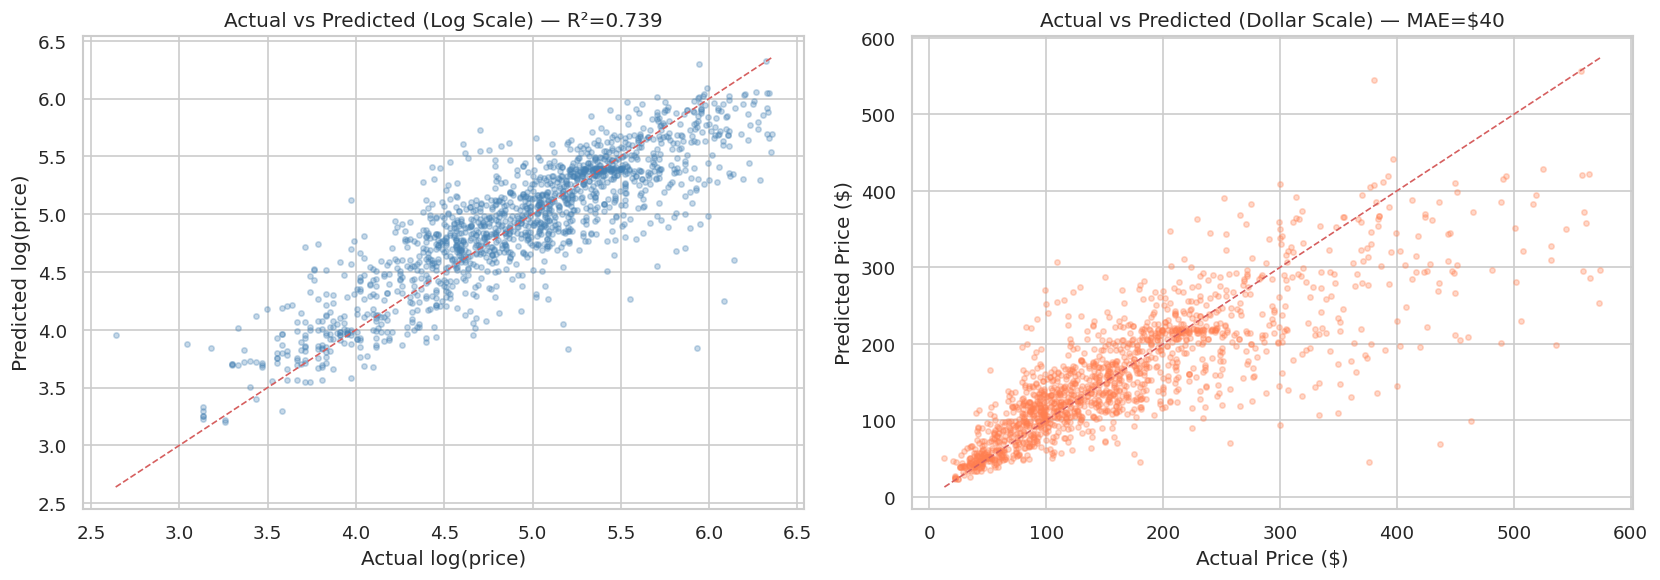

In [ ]:
# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual log(price)")
axes[0].set_ylabel("Predicted log(price)")
axes[0].set_title(f"Actual vs Predicted (Log Scale) — R²={xgb_test_r2:.3f}")

# Dollar scale
axes[1].scatter(actual_dollars, pred_dollars, alpha=0.3, s=10, color="coral")
lims2 = [min(actual_dollars.min(), pred_dollars.min()), max(actual_dollars.max(), pred_dollars.max())]
axes[1].plot(lims2, lims2, "r--", linewidth=1)
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].set_title(f"Actual vs Predicted (Dollar Scale) — MAE=${mae_dollars:.0f}")

plt.tight_layout()
plt.show()

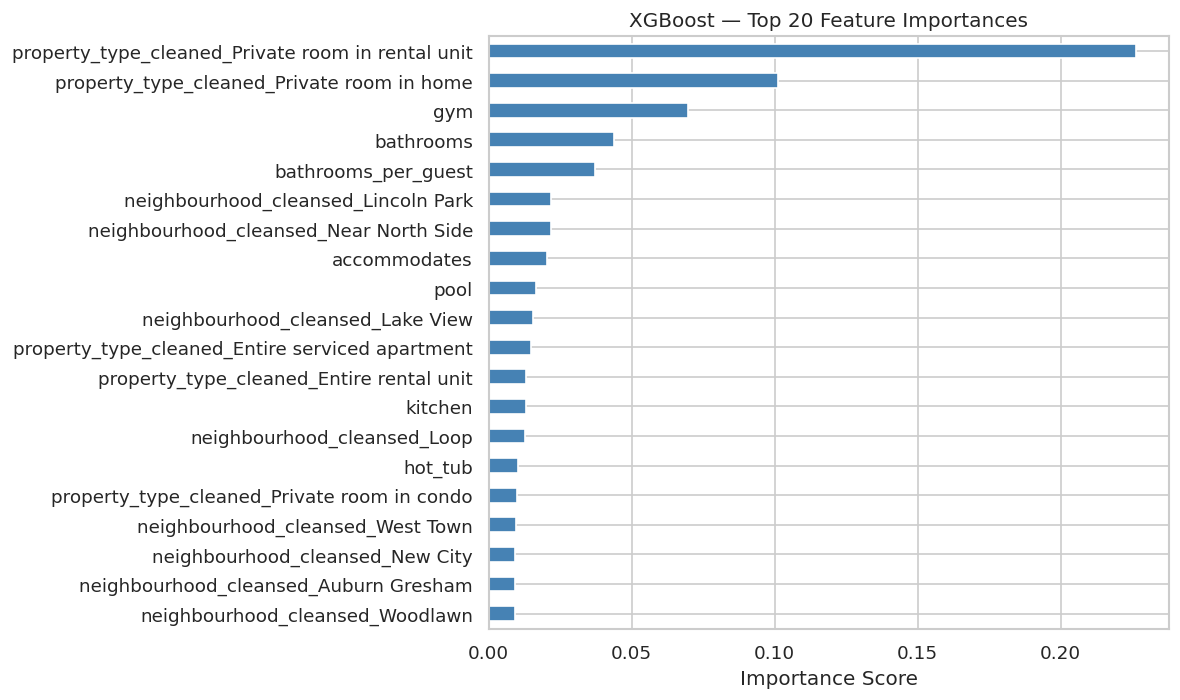

In [ ]:
# Top 20 feature importances
importances = pd.Series(xgb.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.title("XGBoost — Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 7. Export Model & Artifacts

In [ ]:
# Save model and supporting files for deployment
joblib.dump(xgb, "priceit_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

neighborhoods = sorted([col.replace("neighbourhood_cleansed_", "") for col in X.columns if "neighbourhood_cleansed_" in col])
property_types = sorted([col.replace("property_type_cleaned_", "") for col in X.columns if "property_type_" in col])

joblib.dump(neighborhoods, "neighborhoods.pkl")
joblib.dump(property_types, "property_types.pkl")

print(f"Model saved: priceit_model.pkl")
print(f"Neighborhoods: {len(neighborhoods)}")
print(f"Property types: {len(property_types)}")

Model saved: priceit_model.pkl
Neighborhoods: 75
Property types: 10
